In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
from google.colab import drive
drive.mount("/content/drive/")

Mounted at /content/drive/


In [12]:
dataset= pd.read_csv("/content/drive/MyDrive/Datasets/seattle-weather.csv")

In [13]:
dataset.head(5)

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [16]:
dataset_final= dataset[["precipitation","temp_max","temp_min","wind"]].copy()

In [17]:
dataset_final.head(5)

,precipitation,temp_max,temp_min,wind
0,0.0,12.8,5.0,4.7
1,10.9,10.6,2.8,4.5
2,0.8,11.7,7.2,2.3
3,20.3,12.2,5.6,4.7
4,1.3,8.9,2.8,6.1


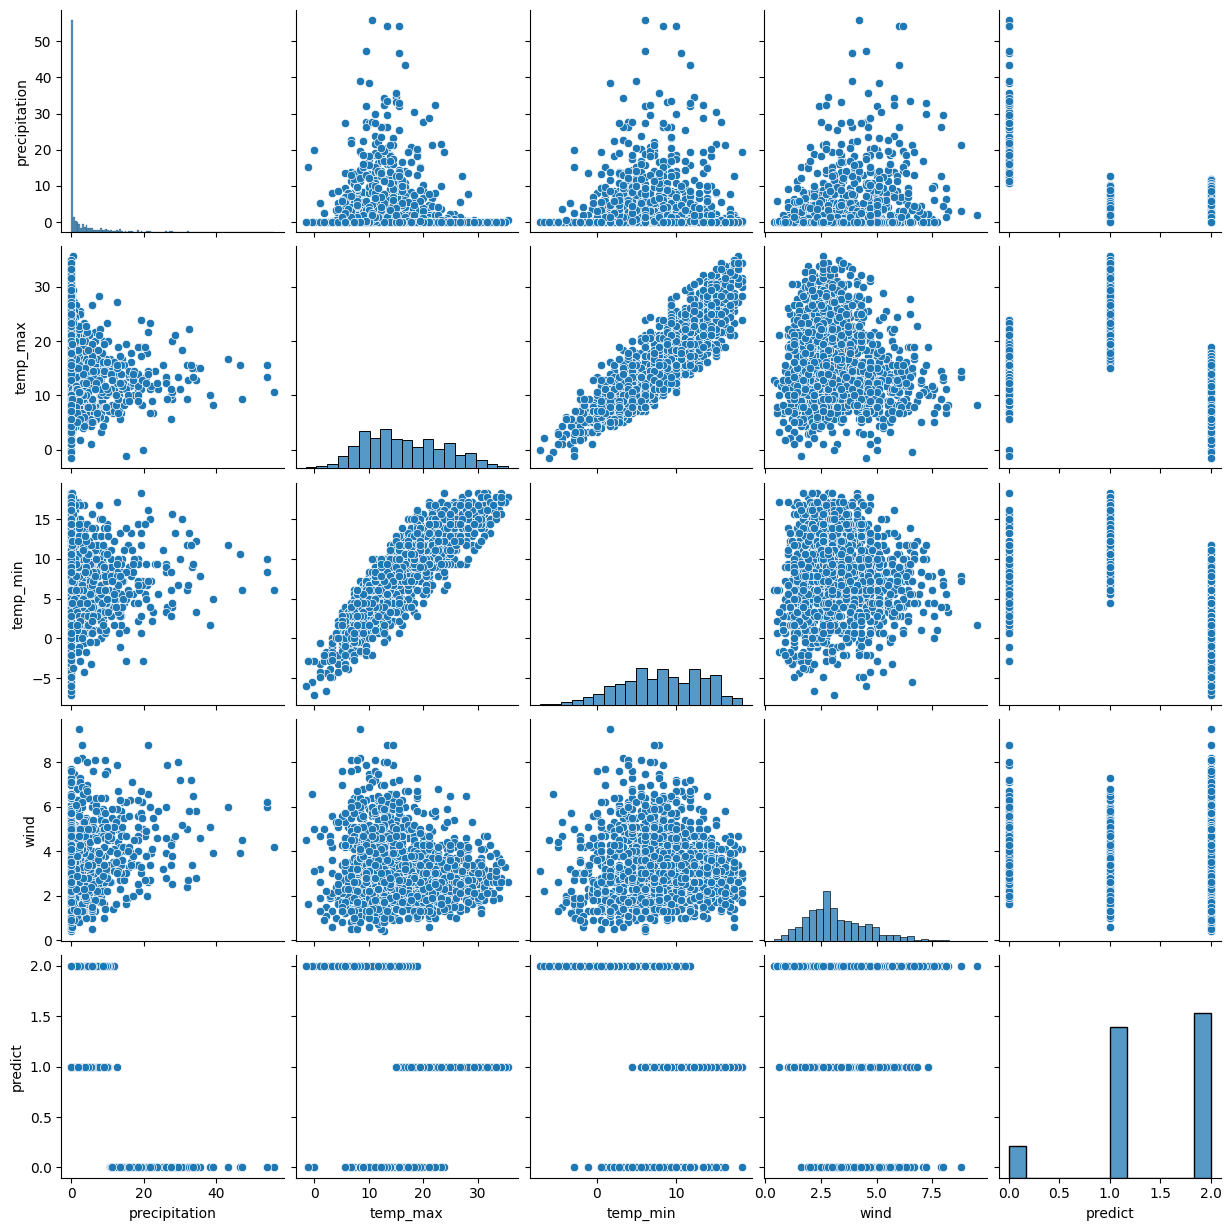

In [34]:
sns.pairplot(dataset_final)
plt.show()

In [21]:
wcss= []
for i in range(2,21):
  km= KMeans(n_clusters=i, init= "k-means++")
  km.fit(dataset_final)
  wcss.append(km.inertia_)

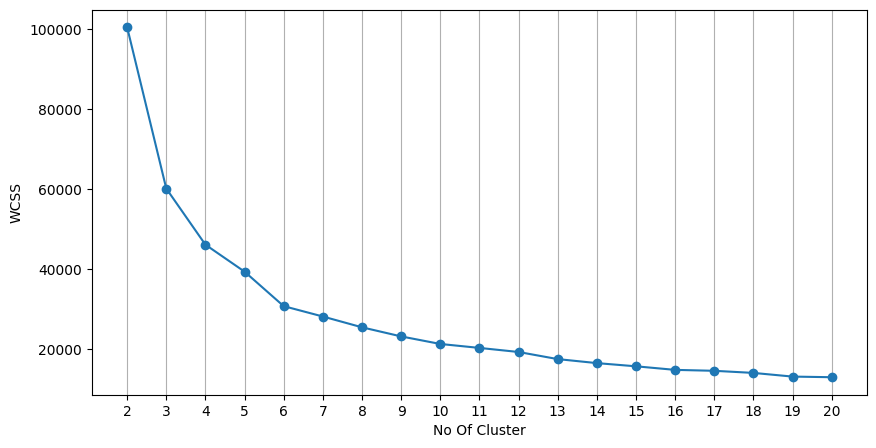

In [22]:
plt.figure(figsize=(10,5))
plt.plot([i for i in range(2,21)],wcss, marker="o")
plt.xlabel("No Of Cluster")
plt.xticks([i for i in range(2,21)])
plt.grid(axis="x")
plt.ylabel("WCSS")
plt.show()

In [23]:
kmm= KMeans(n_clusters=3)
kmm.fit_predict(dataset_final)

array([2, 2, 2, ..., 2, 2, 2], dtype=int32)

In [24]:
kmm= KMeans(n_clusters=3)
dataset_final["predict"]=kmm.fit_predict(dataset_final)

In [25]:
dataset_final.head(5)

,precipitation,temp_max,temp_min,wind,predict
0,0.0,12.8,5.0,4.7,2
1,10.9,10.6,2.8,4.5,2
2,0.8,11.7,7.2,2.3,2
3,20.3,12.2,5.6,4.7,0
4,1.3,8.9,2.8,6.1,2


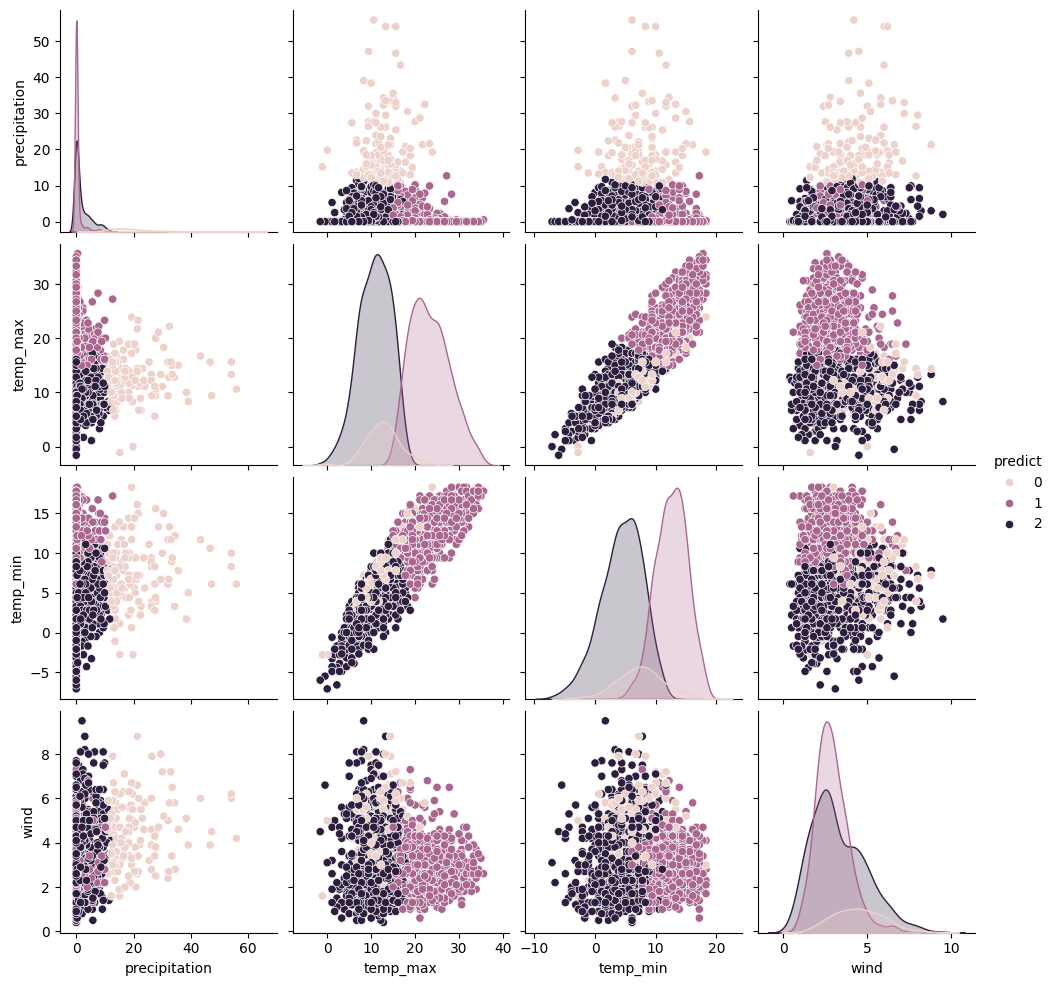

In [30]:
sns.pairplot(dataset_final,hue="predict")
plt.show()

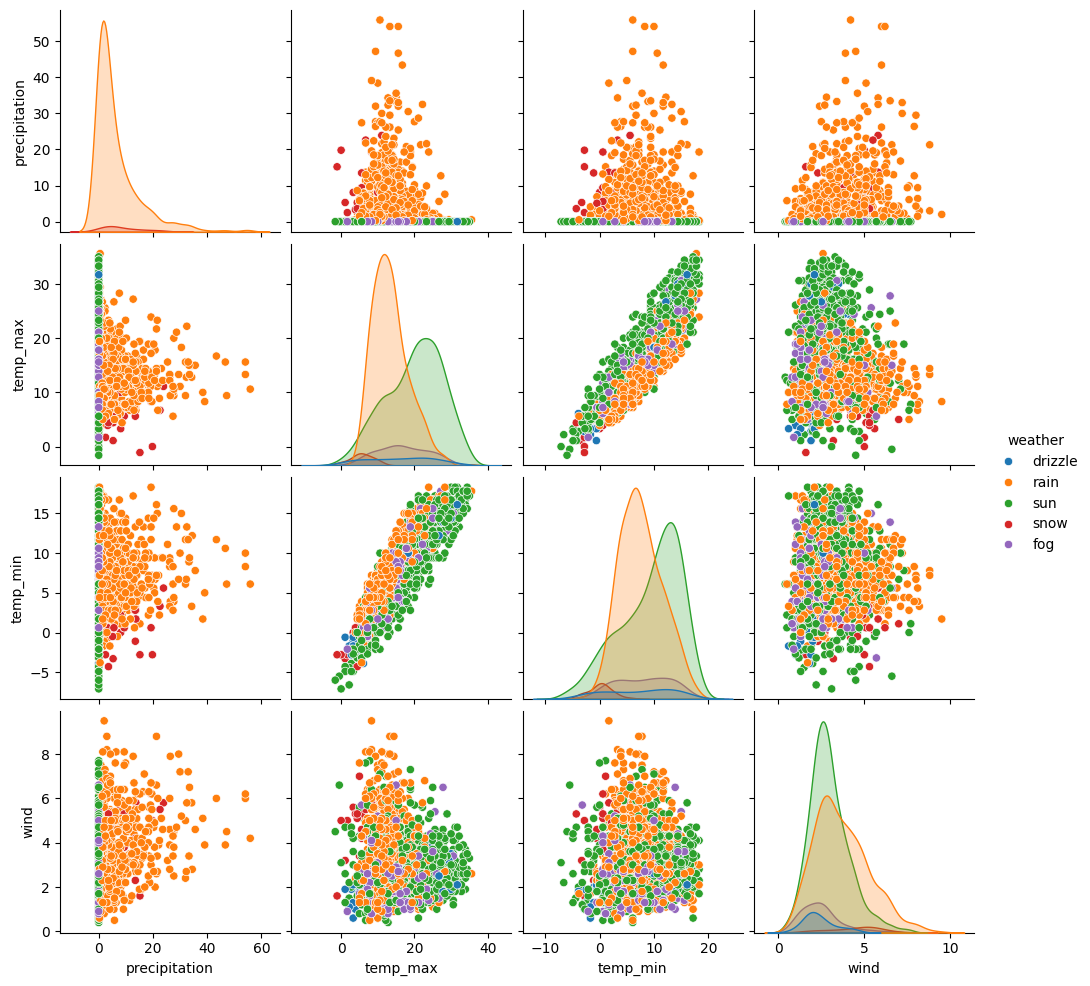

In [32]:
sns.pairplot(dataset,hue="weather")
plt.show()